In [1]:
import pandas as pd
df = pd.read_csv('c:/data/regression/test.csv')
df

,x,y
0,1,1.619379
1,2,1.857290
2,3,2.628194
3,4,2.725426
4,5,3.498926
5,6,3.867042
6,7,4.934539
7,8,4.864829
8,9,5.241539
9,10,5.823689


In [2]:
import torch
X = torch.from_numpy(df['x'].values).unsqueeze(1).float()
y = torch.from_numpy(df['y'].values).unsqueeze(1).float()

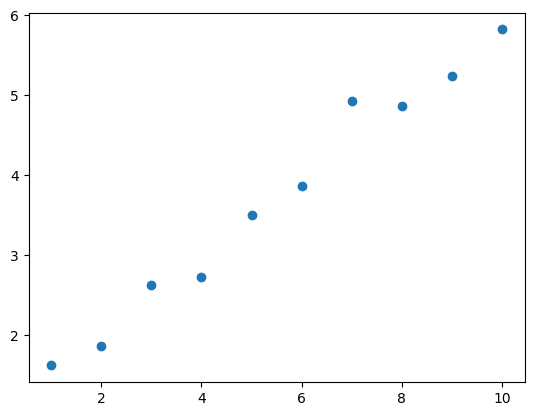

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X,y)
plt.show()

In [4]:
from torch import nn
#단순한 신경망
model = nn.Linear(in_features=1, out_features=1, bias=True)
print(model)
#초기 파라미터
print(model.weight)
print(model.bias)

Linear(in_features=1, out_features=1, bias=True)
Parameter containing:
tensor([[-0.5556]], requires_grad=True)
Parameter containing:
tensor([0.4499], requires_grad=True)


In [5]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.01)
print(model(X)) #predict(학습 전)

tensor([[-0.1057],
        [-0.6614],
        [-1.2170],
        [-1.7726],
        [-2.3282],
        [-2.8839],
        [-3.4395],
        [-3.9951],
        [-4.5508],
        [-5.1064]], grad_fn=<AddmmBackward0>)


In [6]:
for step in range(500):
    prediction = model(X)
    loss = criterion(input=prediction, target=y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f'epoch: {step}, loss: {loss:.3f}')

epoch: 0, loss: 48.785
epoch: 1, loss: 47.798
epoch: 2, loss: 46.821
epoch: 3, loss: 45.855
epoch: 4, loss: 44.900
epoch: 5, loss: 43.956
epoch: 6, loss: 43.022
epoch: 7, loss: 42.100
epoch: 8, loss: 41.189
epoch: 9, loss: 40.290
epoch: 10, loss: 39.402
epoch: 11, loss: 38.526
epoch: 12, loss: 37.661
epoch: 13, loss: 36.809
epoch: 14, loss: 35.968
epoch: 15, loss: 35.140
epoch: 16, loss: 34.324
epoch: 17, loss: 33.520
epoch: 18, loss: 32.728
epoch: 19, loss: 31.948
epoch: 20, loss: 31.181
epoch: 21, loss: 30.426
epoch: 22, loss: 29.683
epoch: 23, loss: 28.953
epoch: 24, loss: 28.235
epoch: 25, loss: 27.529
epoch: 26, loss: 26.836
epoch: 27, loss: 26.155
epoch: 28, loss: 25.486
epoch: 29, loss: 24.830
epoch: 30, loss: 24.185
epoch: 31, loss: 23.553
epoch: 32, loss: 22.933
epoch: 33, loss: 22.325
epoch: 34, loss: 21.728
epoch: 35, loss: 21.143
epoch: 36, loss: 20.570
epoch: 37, loss: 20.009
epoch: 38, loss: 19.459
epoch: 39, loss: 18.920
epoch: 40, loss: 18.393
epoch: 41, loss: 17.877
ep

In [7]:
print(model(X)) #predict(학습 후)

tensor([[1.7607],
        [2.2041],
        [2.6476],
        [3.0910],
        [3.5345],
        [3.9779],
        [4.4214],
        [4.8648],
        [5.3083],
        [5.7517]], grad_fn=<AddmmBackward0>)


In [8]:
def mse_loss(preds, trues):
    return torch.sum((preds - trues)**2) / preds.view(-1).shape[0]

mse_loss(model(X), y)

tensor(0.0561, grad_fn=<DivBackward0>)

In [11]:
print('학습 후 오차:',loss.data.item())
print('가중치:',model.weight.data.item())
model.bias.data.item()

학습 후 오차: 0.056119341403245926
가중치: 0.4434518814086914


1.3172129392623901

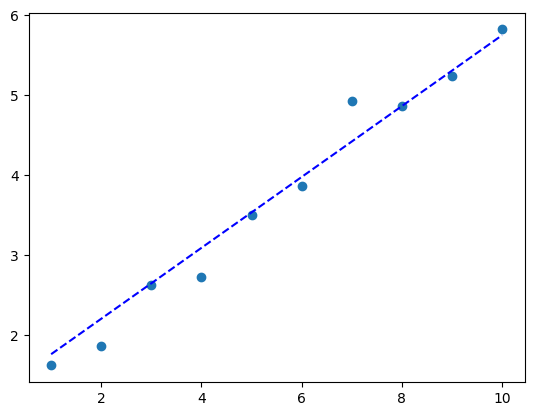

In [10]:
def display_results(model, x, y):
    pred = model(x)
    plt.scatter(x.data.numpy(), y.data.numpy())
    plt.plot(x.data.numpy(), pred.data.numpy(), 'b--')
    plt.show()
display_results(model, X, y)